In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_excel("https://raw.githubusercontent.com/naimdotcom/Machine-Learning/main/data/Concrete_Data.xls")

In [ ]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [ ]:
FEATURES = [
    "Cement (component 1)(kg in a m^3 mixture)",
    "Blast Furnace Slag (component 2)(kg in a m^3 mixture)",
    "Fly Ash (component 3)(kg in a m^3 mixture)",
    "Water  (component 4)(kg in a m^3 mixture)",
    "Superplasticizer (component 5)(kg in a m^3 mixture)",
    "Coarse Aggregate  (component 6)(kg in a m^3 mixture)",
    "Fine Aggregate (component 7)(kg in a m^3 mixture)",
    "Age (day)"
]
TARGETS = ["Concrete compressive strength(MPa, megapascals) "]

In [ ]:
df.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
"Concrete compressive strength(MPa, megapascals)",0


In [ ]:
X = df[FEATURES].values
Y = df[TARGETS].values

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1030, 8)
Y shape: (1030, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 824
Testing set size: 206


In [ ]:
avg = X_train.mean(axis=0)
std = X_train.std(axis=0)


X_train = (X_train - avg) / std
X_test = (X_test - avg) / std

y_avg = np.mean(y_train)
y_std = np.std(y_train)

y_train = (y_train - y_avg) / y_std
y_test = (y_test - y_avg) / y_std

In [ ]:
def regression(x,w,b):
  return np.dot(x, w) + b

In [ ]:
def compute_cost(x,y,w,b):
  m = x.shape[0]
  fwb = regression(x,w,b)
  cost = np.sum((fwb - y)**2)/(2*m)

  return cost

In [ ]:
def compute_gradient(x,y,w,b):
  m=x.shape[0]
  fwb = regression(x,w,b)
  learning_error = fwb - y
  # print(
  #     f"X shape: {x.shape}",
  #     f"Y Shpae: {y.shape}",
  #     f"Learning error: {learning_error.shape}"
  # )
  dj_w = np.dot(x.T, learning_error)/m
  dj_b = np.sum(learning_error, axis=0)/m

  return dj_w, dj_b

In [ ]:
def gradient_descent(x,y,alp=0.01, iteration=50000):
  n_features = x.shape[1]
  n_output = y.shape[1]
  w = np.zeros((n_features, n_output))
  b = np.zeros((n_output,))
  cost_history = []

  for i in range(iteration):
    dj_w, dj_b = compute_gradient(x,y,w,b)
    w = w - alp * dj_w
    b = b - alp * dj_b
    cost = compute_cost(x,y,w,b)
    cost_history.append(cost)
  return w, b, cost_history

In [ ]:
w_final, b_final, cost_hist = gradient_descent(X_train, y_train)

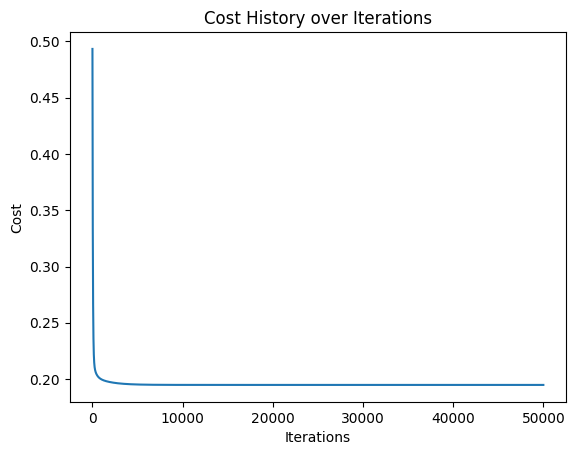

Final Weights: 
[[ 0.75862889]
 [ 0.55965707]
 [ 0.31181754]
 [-0.17158871]
 [ 0.10923344]
 [ 0.08307773]
 [ 0.11553888]
 [ 0.41755501]]
Final Bias: [-2.5535938e-15]
Test Mean Squared Error: 0.34


In [ ]:
plt.plot(cost_hist)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost History over Iterations")
plt.show()

# Evaluate on test set
X_test_np = X_test
y_test_np = y_test

predictions = regression(X_test_np, w_final, b_final)
mse_final = np.mean((predictions - y_test_np)**2)

print(f"Final Weights: \n{w_final}")
print(f"Final Bias: {b_final}")
print(f"Test Mean Squared Error: {mse_final:.2f}")

In [ ]:
prediction = regression(X_test, w_final, b_final)

# RMSE
rmse = np.sqrt(np.mean((prediction - y_test)**2))
print("RMSE:", rmse)

# r^2
ss_res = np.sum((prediction - y_test)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)
print("r^2:", r2)

RMSE: 0.581243003256693
r^2: 0.6275416060676016
